In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

In [14]:
output_notebook()



Loading BokehJS ...

In [15]:
df = pd.read_csv('techstore_chile_2024.csv')
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")
print(df.dtypes)
print(df.isnull().sum())





Cantidad de filas: 300
Cantidad de columnas: 7
mes                  int64
categoria              str
unidades             int64
precio_unitario    float64
ingresos           float64
nps                  int64
devueltos            int64
dtype: object
mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64


### Actividad 1
El dataset analizado consta de 300 filas y 7 columnas.Presenta tipos numéricos enteros (int64) , valores decimales (float64) , y tipo texto u objeto (object) . Finalmente, no se registran valores faltantes ni nulos.


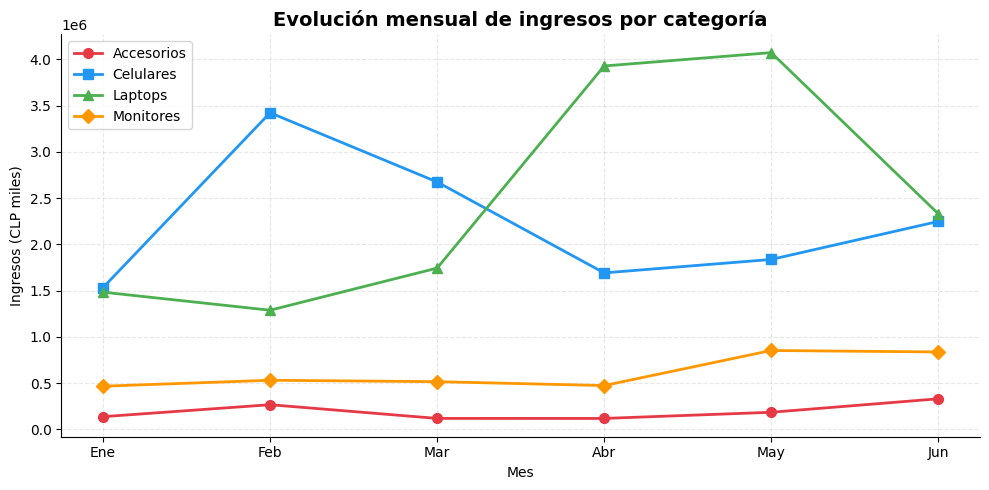

In [19]:
 

#Grafico
ingresos_mes_cat = df.groupby(['mes', 'categoria'])['ingresos'].sum().reset_index()

categorias = df['categoria'].unique()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
colores = {'Accesorios': '#E63946', 'Celulares': '#2196F3', 'Laptops': '#4CAF50', 'Monitores': '#FF9800'}
marcadores = {'Accesorios': 'o', 'Celulares': 's', 'Laptops': '^', 'Monitores': 'D'}

fig, ax = plt.subplots(figsize=(10, 5))

for cat in categorias:
    subset = ingresos_mes_cat[ingresos_mes_cat['categoria'] == cat].sort_values('mes')
    ax.plot(
        subset['mes'], subset['ingresos'],
        label=cat,
        color=colores[cat],
        marker=marcadores[cat],
        linewidth=2,
        markersize=7
    )

ax.set_title('Evolución mensual de ingresos por categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (CLP miles)')
ax.set_xticks(range(1, 7))
ax.set_xticklabels(meses_labels)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend() # Agregué la leyenda para que se vean las categorías

plt.tight_layout()
plt.show()

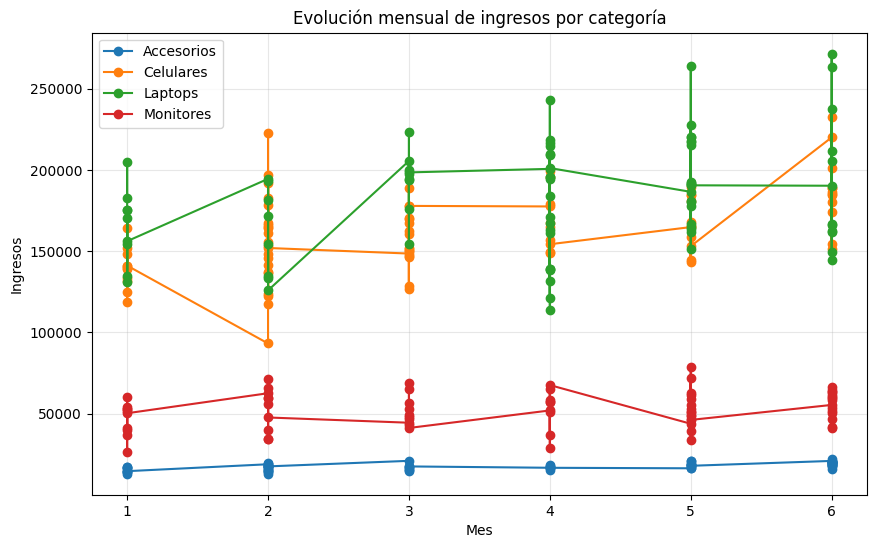

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
categorias = df['categoria'].unique()

for cat in categorias:
    subset = df[df['categoria'] == cat]
    ax.plot(subset['mes'], subset['ingresos'], marker='o', label=cat)

ax.set_title("Evolución mensual de ingresos por categoría")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos")
ax.set_xticks(range(1, 7)) 
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### Ejercicio 1

3. ¿Que categoria presenta la mayor tasa de crecimiento mensual? 
Laptops muestra la mayor tasa de crecimiento mensual sostenido. Esto podria deberse a campañas de temporada (vuelta a clases, ofertas de mitad de año) o a lanzamientos de nuevos modelos que impulsan la demanda .

4. ¿Por que se utiliza ax.set_xticks() junto con ax.set_xticklabels()?  
ax.set_xticks() define en qué posiciones numéricas del eje se colocan las marcas, mientras que ax.set_xticklabels() asigna el texto visible a cada marca. Si solo se usa set_xticklabels() sin definir primero los ticks, matplotlib puede aplicar las etiquetas a posiciones inesperadas o generar una advertencia. Usados juntos garantizan una correspondencia exacta entre posicion y etiqueta.

6. ¿Que ventaja aporta el parametro alpha en ax.grid()?
El parametro alpha controla la transparencia de la cuadricula (0 = invisible, 1 = opaco). Usar alpha=0.3 hace que la grilla sea una guía visual sutil sin competir con las líneas de datos. Con alpha=1.0 la grilla se vuelve igual de prominente que las series, dificultando la lectura del gráfico.

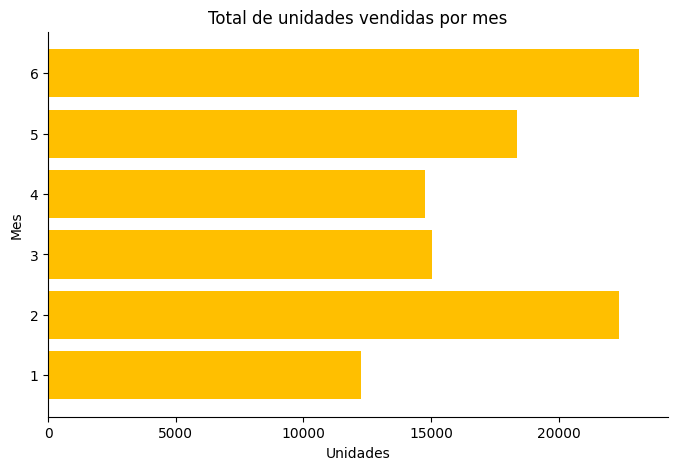

In [21]:
unidades_mes = df.groupby('mes')['unidades'].sum()
colores = ['orange' if total > 1400 else 'skyblue' for total in unidades_mes]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(unidades_mes.index, unidades_mes.values, color=colores)
ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades')
ax.set_ylabel('Mes')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

2. ¿Cuál es la diferencia entre ax.bar() y ax.barh()? ¿En qué contextos preferiría cada uno?
   R:ax.bar() genera un gráfico de barras verticales, mientras que ax.barh() genera barras horizontales.
3. ¿Por qué se ocultan los ejes superior y derecho con ax.spines['top'].set_visible(False)? ¿Qué
efecto visual produce?
   R:Se ocultan para eliminar bordes innecesarios que no aportan información.Esto produce un efecto visual mucho más limpio, enfocado y menos saturado, evitando que los datos queden encerrados en un recuadro.
 


   

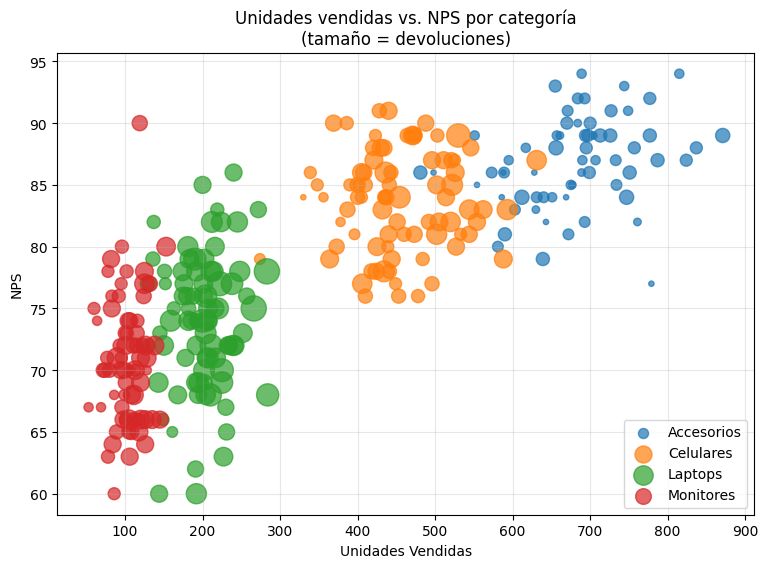

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

categorias = df['categoria'].unique()

for cat in categorias:
    subset = df[df['categoria'] == cat]
    ax.scatter(subset['unidades'], subset['nps'], 
               s=subset['devueltos'] * 15, 
               label=cat, alpha=0.7)

ax.set_title("Unidades vendidas vs. NPS por categoría\n(tamaño = devoluciones)")
ax.set_xlabel("Unidades Vendidas")
ax.set_ylabel("NPS")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

2. No existe una relación lineal directa entre vender un mayor volumen de unidades y tener un mejor nivel de satisfacción. La tendencia se agrupa según la naturaleza de cada producto y no por sus ventas
3.  Se multiplica por 15 para escalar los puntos visualmente. Si las devoluciones son muy pequeñas (ej. 1 o 2), los puntos serían diminutos e invisibles. 

4. Dimensión X = Volumen de ventas (Unidades), Dimensión Y = Nivel de satisfacción (NPS), Color = Categoría del producto, Tamaño = Cantidad de devoluciones.

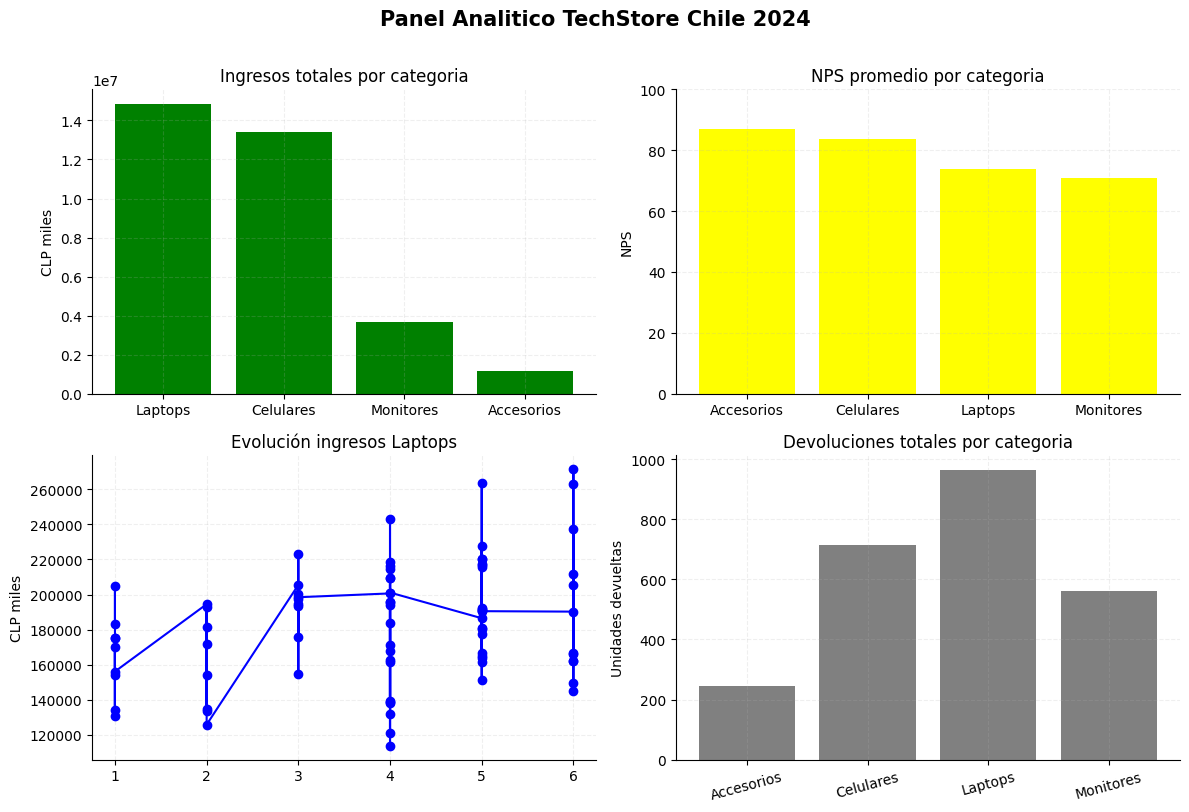

In [24]:
ingresos_cat = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_cat = df.groupby('categoria')['nps'].mean()
dev_cat = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Panel Analitico TechStore Chile 2024', fontsize=15, fontweight='bold', y=1.01)

axes[0,0].bar(ingresos_cat.index, ingresos_cat.values, color='green')
axes[0,0].set_title('Ingresos totales por categoria')
axes[0,0].set_ylabel('CLP miles')


axes[0,1].bar(nps_cat.index, nps_cat.values, color='yellow')
axes[0,1].set_title('NPS promedio por categoria')
axes[0,1].set_ylabel('NPS')
axes[0,1].set_ylim(0, 100)


axes[1,0].plot(laptops['mes'], laptops['ingresos'], marker='o', color='blue')
axes[1,0].set_title('Evolución ingresos Laptops')
axes[1,0].set_xticks(range(1, 7))
axes[1,0].set_ylabel('CLP miles')


axes[1,1].bar(dev_cat.index, dev_cat.values, color='gray')
axes[1,1].set_title('Devoluciones totales por categoria')
axes[1,1].set_ylabel('Unidades devueltas')
axes[1,1].tick_params(axis='x', rotation=15)

for ax in axes.flat:
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1. El panel nos permite ver un panorama completo: cruzando la información notamos que la categoría que genera más ingresos  también es la que tiene X devoluciones, lo cual afecta (o no) a su NPS promedio." .

2. fig.suptitle() agrega un título maestro que abarca la figura completa (todos los subgráficos), mientras que ax.set_title() solo le da título a un subgráfico específico individual.

3. axes.flat aplana la matriz 2x2 de gráficos en una sola lista (1D). Esto simplifica el código permitiendo iterar sobre los 4 subgráficos con un solo ciclo for, evitando hacer ciclos anidados.

In [26]:

ingresos_mes = df.groupby('mes').agg({'ingresos':'sum', 'unidades':'sum'}).reset_index()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ingresos_mes['mes_label'] = meses_labels[:len(ingresos_mes)]
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f} K')

source = ColumnDataSource(ingresos_mes)


hover = HoverTool(tooltips=[
    ('Mes', '@mes_label'),
    ('Ingresos', '@ingresos_fmt'),
    ('Unidades', '@unidades')  
])


p = figure(x_range=ingresos_mes['mes_label'].tolist(), 
           title="Ingresos y Unidades por Mes", 
           toolbar_location=None, tools=[hover], height=400)

p.vbar(x='mes_label', top='ingresos', source=source, width=0.65,
       color='yellow', line_color='black', alpha=0.85)

p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'

show(p)

1. El ColumnDataSource es la estructura de datos central de Bokeh. Su gran ventaja es que agrupa todos los datos en un solo objeto centralizado (muy similar a un DataFrame de Pandas). Al usarlo en lugar de listas sueltas, permitimos que herramientas interactivas como el HoverTool puedan acceder a datos adicionales que no se están dibujando en los ejes X e Y
2. La cadena @mes_label se define dentro de una tupla en el parámetro tooltips de la herramienta HoverTool. El símbolo arroba (@) es la sintaxis interna que usa Bokeh para vincular el texto con los datos. Su relación directa es que le indica al gráfico que debe buscar una clave (o columna) que se llame exactamente mes_label dentro del ColumnDataSource
